## Matrix multiplication from foundations

The *foundations* we'll assume throughout this course are:

- Python
- matplotlib
- The Python standard library
- Jupyter notebooks and nbdev

In [ ]:
from pathlib import Path
import pickle, gzip, math, os, time, shutil, matplotlib as mpl, matplotlib.pyplot as plt

## Get data

In [ ]:
MNIST_URL='https://github.com/mnielsen/neural-networks-and-deep-learning/blob/master/data/mnist.pkl.gz?raw=true'

In [ ]:
path_data = Path('data')
path_data.absolute()

Path('/app/data/deeplearning/course22p2_zh/nbs/data')

In [ ]:
path_data.mkdir(exist_ok=True)

In [ ]:
path_gz = path_data/'mnist.pkl.gz'

[urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) - (read the docs!)

In [ ]:
from urllib.request import urlretrieve
if not path_gz.exists(): urlretrieve(MNIST_URL, path_gz)

In [ ]:
urlretrieve??


```python
def urlretrieve(url, filename=None, reporthook=None, data=None):
    """
    Retrieve a URL into a temporary location on disk.

    Requires a URL argument. If a filename is passed, it is used as
    the temporary file location. The reporthook argument should be
    a callable that accepts a block number, a read size, and the
    total file size of the URL target. The data argument should be
    valid URL encoded data.

    If a filename is passed and the URL points to a local resource,
    the result is a copy from local file to new file.

    Returns a tuple containing the path to the newly created
    data file as well as the resulting HTTPMessage object.
    """
    url_type, path = _splittype(url)

    with contextlib.closing(urlopen(url, data)) as fp:
        headers = fp.info()

        # Just return the local path and the "headers" for file://
        # URLs. No sense in performing a copy unless requested.
        if url_type == "file" and not filename:
            return os.path.normpath(path), headers

        # Handle temporary file setup.
        if filename:
            tfp = open(filename, 'wb')
        else:
            tfp = tempfile.NamedTemporaryFile(delete=False)
            filename = tfp.name
            _url_tempfiles.append(filename)

        with tfp:
            result = filename, headers
            bs = 1024*8
            size = -1
            read = 0
            blocknum = 0
            if "content-length" in headers:
                size = int(headers["Content-Length"])

            if reporthook:
                reporthook(blocknum, bs, size)

            while block := fp.read(bs):
                read += len(block)
                tfp.write(block)
                blocknum += 1
                if reporthook:
                    reporthook(blocknum, bs, size)

    if size >= 0 and read < size:
        raise ContentTooShortError(
            "retrieval incomplete: got only %i out of %i bytes"
            % (read, size), result)

    return result
```

**File:** `/usr/local/lib/python3.12/urllib/request.py`

How to ensure _url_tempfiles exist

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great question! The `_url_tempfiles` variable is a **module-level global** in `urllib.request`. It's created when the module is first imported.

Here's the key: when you call `urlretrieve(url, filename)`, if `filename` is not provided (or is `None`), the function creates a **temporary file** and appends its path to `_url_tempfiles`. This way, `urlcleanup()` can later find and delete those temp files.

But in your code, you *are* providing a filename (`path_gz`), so `urlretrieve` doesn't add anything to `_url_tempfiles` — it saves directly to your specified path.

So `_url_tempfiles` may not exist in the user-facing sense because:
1. It's a private name (underscore prefix) — not meant for direct access.
2. It's only populated when `urlretrieve` creates temporary files (which doesn't happen when you specify a filename).

If you wanted to inspect it (just for learning), you could do:

```python
import urllib.request
# It's a module attribute
print(urllib.request._url_tempfiles)
```

This would show an empty list if you've only called `urlretrieve` with a filename, or a list of temp file paths if temporary files were created.

Does that answer your question, or would you like to dig deeper into how temporary file handling works in Python?

<details class='token-usage-details'><summary>$0.0003</summary>

`total=7,917 | in=7,554 | out=363 | cached=88.1% | reasoning=57 | searches=0 | $0.0003`

</details>


In [ ]:
import urllib.request
urllib.request.urlcleanup??


```python
def urlcleanup():
    """Clean up temporary files from urlretrieve calls."""
    for temp_file in _url_tempfiles:
        try:
            os.unlink(temp_file)
        except OSError:
            pass

    del _url_tempfiles[:]
    global _opener
    if _opener:
        _opener = None
```

**File:** `/usr/local/lib/python3.12/urllib/request.py`

In [ ]:
!ls -lh data

total 17M
-rw-rw-r-- 1 solveit solveit 17M May 12 02:07 mnist.pkl.gz


In [ ]:
with gzip.open(path_gz, 'rb') as f: ((x_train, y_train), (x_valid, y_valid), (x_test, y_test)) = pickle.load(f, encoding='latin-1')

/tmp/ipykernel_6566/1867874043.py:1: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  with gzip.open(path_gz, 'rb') as f: ((x_train, y_train), (x_valid, y_valid), (x_test, y_test)) = pickle.load(f, encoding='latin-1')


In [ ]:
x_train.shape, y_train.shape, x_valid.shape, y_valid.shape, x_test.shape, y_test.shape

((50000, 784), (50000,), (10000, 784), (10000,), (10000, 784), (10000,))

In [ ]:
x_train[0].shape

(784,)

In [ ]:
lst1 = list(x_train[0])
vals = lst1[200:210]
vals

[np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.19140625),
 np.float32(0.9296875),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125)]

In [ ]:
def chunks(x, sz):
    for i in range(0, len(x), sz): yield x[i:i+sz]

In [ ]:
list(chunks(vals, 5))

[[np.float32(0.0),
  np.float32(0.0),
  np.float32(0.0),
  np.float32(0.19140625),
  np.float32(0.9296875)],
 [np.float32(0.98828125),
  np.float32(0.98828125),
  np.float32(0.98828125),
  np.float32(0.98828125),
  np.float32(0.98828125)]]

Why return 10 items?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great question! The slice `x_train[0][200:210]` gives you 10 items because of how Python slicing works:

- `[200:210]` means "start at index 200, go up to **but not including** index 210"
- `210 - 200 = 10` items

So the 10 values represent 10 consecutive pixels from the first MNIST image — specifically pixels 200 through 209 (0-indexed).

Then `chunks(vals, 5)` splits those 10 values into 2 groups of 5 each, which is why you see 2 lists of 5 numbers.

Is that what you were wondering about, or were you asking something else?

<details class='token-usage-details'><summary>$0.0005</summary>

`total=8,739 | in=8,252 | out=487 | cached=80.7% | reasoning=337 | searches=0 | $0.0005`

</details>


What's the behavior when listing a generator?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good question! When you call `list()` on a generator, it **exhausts** the generator — meaning it asks the generator for every value it can produce and collects them all into a list.

In the code you ran:

```python
list(chunks(vals, 5))
```

The generator `chunks(vals, 5)` keeps yielding chunks of 5 items from `vals` until there's nothing left. `list()` pulls all those yielded values and puts them in a list.

You can think of it like this — `list()` essentially does:

```python
result = []
for chunk in chunks(vals, 5):
    result.append(chunk)
```

One important thing: once you exhaust a generator with `list()` (or a `for` loop, or `next()` called until `StopIteration`), **it's empty**. If you tried to loop over it again, you'd get nothing.

Want to test that out?

<details class='token-usage-details'><summary>$0.0004</summary>

`total=8,738 | in=8,467 | out=271 | cached=86.2% | reasoning=72 | searches=0 | $0.0004`

</details>


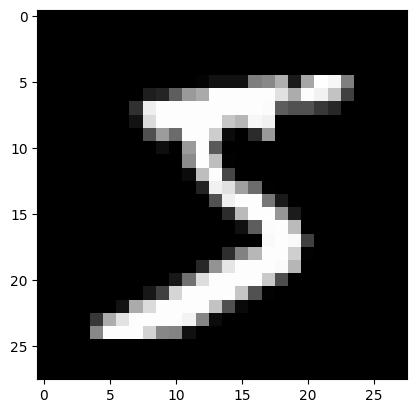

In [ ]:
mpl.rcParams['image.cmap'] = 'gray'
plt.imshow(list(chunks(lst1, 28)));

[islice](https://docs.python.org/3/library/itertools.html#itertools.islice)

In [ ]:
from itertools import count
count?

```python
def count(
    args:VAR_POSITIONAL, kwargs:VAR_KEYWORD
):

```



```
Return a count object whose .__next__() method returns consecutive values.

Equivalent to:
    def count(firstval=0, step=1):
        x = firstval
        while 1:
            yield x
            x += step
```



**Type:** type

In [ ]:
from itertools import islice

In [ ]:
it = iter(vals)
islice(it, 5)

In [ ]:
type((islice(it, 5))).mro()

[itertools.islice, object]

In [ ]:
from collections.abc import Generator, Iterable, Iterator

In [ ]:
isinstance(islice(it, 5), Generator)

False

In [ ]:
isinstance(islice(it, 5), Iterator)

True

In [ ]:
isinstance(islice(it, 5), Iterable)

True

In [ ]:
list(islice(it, 5))

[np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.19140625),
 np.float32(0.9296875)]

In [ ]:
list(islice(it, 5))

[np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125),
 np.float32(0.98828125)]

In [ ]:
list(islice(it, 5))

[]

In [ ]:
it = iter(lst1)
img = list(iter(lambda: list(islice(it, 28)), []))

Please explain the last code cell

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Sure! Let's break it down piece by piece.

**First:** `it = iter(lst1)` turns the flat list of 784 pixel values into an **iterator** — so we can consume items one chunk at a time.

**Then the tricky part:**

```python
iter(lambda: list(islice(it, 28)), [])
```

The two-argument form of `iter(callable, sentinel)` repeatedly calls the `callable`, and **stops** when it returns the `sentinel` value (`[]`).

- `islice(it, 28)` grabs the next 28 items from the iterator `it`
- `list(...)` turns that into a list of 28 pixel values
- So each call to the lambda gives you one **row** of the image

When `it` runs out, `islice` returns fewer than 28 items (or none), `list(...)` of that is `[]`, which matches the sentinel — so `iter()` stops.

**Finally:** `list(...)` collects all those rows into one list.

So `img` ends up as a list of 28 rows, each with 28 pixel values — the flat 784-pixel array reshaped into a 28×28 grid for displaying the image.

Does that make sense? Want me to show a simpler alternative for doing the same thing?

<details class='token-usage-details'><summary>$0.0003</summary>

`total=11,216 | in=10,533 | out=683 | cached=99.6% | reasoning=399 | searches=0 | $0.0003`

</details>


In [ ]:
iter?

```python
def iter(
    
):

```



```
iter(iterable) -> iterator
iter(callable, sentinel) -> iterator

Get an iterator from an object.  In the first form, the argument must
supply its own iterator, or be a sequence.
In the second form, the callable is called until it returns the sentinel.
```



**Type:** builtin_function_or_method

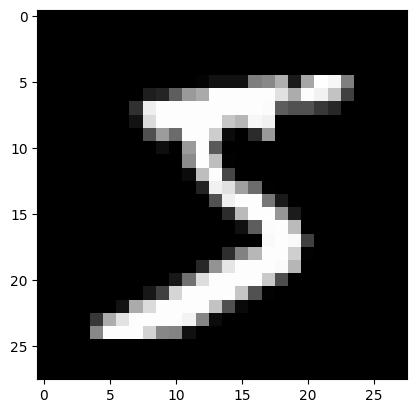

In [ ]:
plt.imshow(img);

## Matrix and tensor

In [ ]:
img[20][15]

np.float32(0.98828125)

In [ ]:
class Matrix:
    def __init__(self, xs): self.xs = xs
    def __getitem__(self, idxs):
        # print(idxs, type(idxs))
        return self.xs[idxs[0]][idxs[1]]

In [ ]:
m = Matrix(img)
m[20,15]

np.float32(0.98828125)

In [ ]:
import torch
from torch import tensor

In [ ]:
tensor([1,2,3])

tensor([1, 2, 3])

In [ ]:
map?

```python
def map(
    args:VAR_POSITIONAL, kwargs:VAR_KEYWORD
):

```



```
map(func, *iterables) --> map object

Make an iterator that computes the function using arguments from
each of the iterables.  Stops when the shortest iterable is exhausted.
```



**Type:** type

In [ ]:
x_train,y_train,x_valid,y_valid = map(tensor, (x_train,y_train,x_valid,y_valid))
x_train.shape

torch.Size([50000, 784])


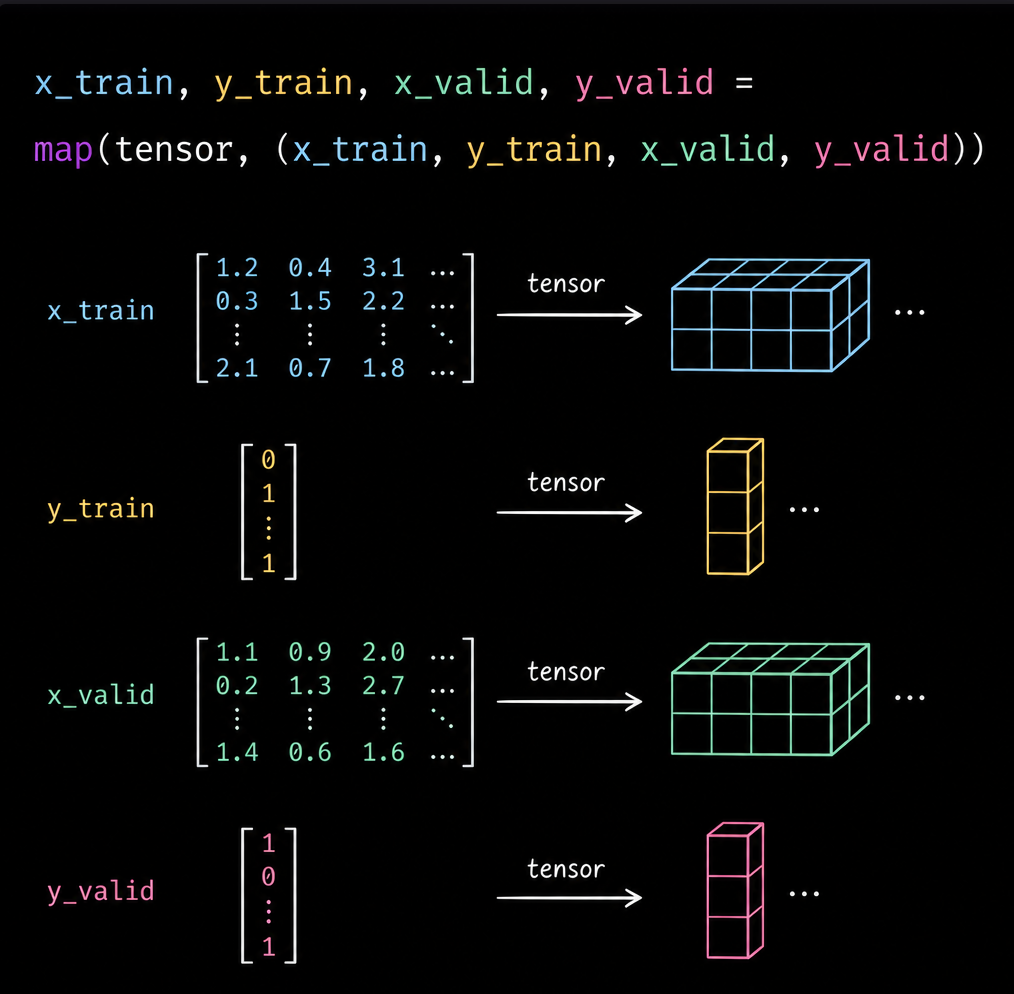


In [ ]:
x_train.type()

'torch.FloatTensor'

In [ ]:
type(x_train)

torch.Tensor

[Tensor](https://pytorch.org/docs/stable/tensors.html)

In [ ]:
imgs = x_train.reshape((-1,28,28))
imgs.shape

torch.Size([50000, 28, 28])

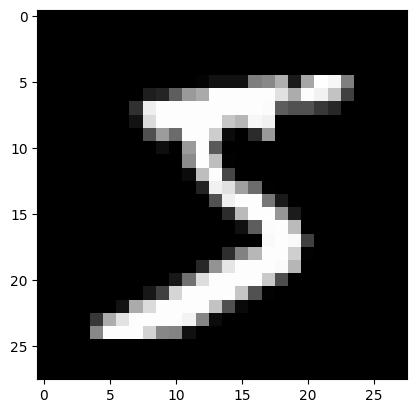

In [ ]:
plt.imshow(imgs[0]);

In [ ]:
imgs[0,20,15]

tensor(0.9883)

In [ ]:
n,c = x_train.shape
y_train, y_train.shape

(tensor([5, 0, 4,  ..., 8, 4, 8]), torch.Size([50000]))

In [ ]:
n, c

(50000, 784)

In [ ]:
min(y_train),max(y_train)

(tensor(0), tensor(9))

In [ ]:
y_train.min(), y_train.max()

(tensor(0), tensor(9))

## Random numbers

Based on the Wichmann Hill algorithm used before Python 2.3.

Introduce Wichmann Hill algorithm and without much math.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The **Wichmann–Hill algorithm** is a **pseudorandom number generator (PRNG)** — a recipe for creating numbers that *look* random, even though they're generated by a deterministic formula.

Here's the key idea in simple terms:

- **Seed**: You start with a small set of numbers (the "seed").
- **Three simple formulas**: The algorithm runs three separate formulas (each involving multiplication and modulo — basically "divide and keep the remainder"). These three numbers are combined to produce a final random-looking number between 0 and 1.
- **Next number**: Each time you ask for a random number, the formulas update and produce a new one.

Why three formulas instead of one? It gives a **much longer period** — meaning you can generate *many* numbers before the sequence starts repeating (around 6.95 × 10¹² values) — much better than simpler schemes.

This was used in Python's `random` module before Python 2.3, when it was replaced by the Mersenne Twister (which is faster and has an even longer period).

Want to try implementing a mini-version to see how it works?

<details class='token-usage-details'><summary>$0.0004</summary>

`total=12,854 | in=12,545 | out=309 | cached=90.8% | reasoning=66 | searches=0 | $0.0004`

</details>


In [ ]:
rnd_state = None
def seed(a):
    global rnd_state
    a, x = divmod(a, 30268)
    a, y = divmod(a, 30306)
    a, z = divmod(a, 30322)
    rnd_state = int(x)+1, int(y)+1, int(z)+1

In [ ]:
divmod?

```python
def divmod(
    x, y
):

```



```
Return the tuple (x//y, x%y).  Invariant: div*y + mod == x.
```



**Type:** builtin_function_or_method

In [ ]:
seed(42)
rnd_state

(43, 1, 1)

In [ ]:
def rand():
    global rnd_state
    x, y, z = rnd_state
    x = (171 * x) % 30269
    y = (172 * y) % 30307
    z = (170 * z) % 30323
    rnd_state = x,y,z
    return (x/30269 + y/30307 + z/30323) % 1.0

In [ ]:
rand(),rand(),rand()

(0.25420336316883324, 0.46884405296716114, 0.19540525690312815)

In [ ]:
if os.fork(): print(f'In parent: {rand()}')
else:
    print(f'In child: {rand()}')
    os._exit(os.EX_OK)

In parent: 0.28886109883281286


/tmp/ipykernel_6566/2916155298.py:1: DeprecationWarning: This process (pid=6566) is multi-threaded, use of fork() may lead to deadlocks in the child.
  if os.fork(): print(f'In parent: {rand()}')


In child: 0.28886109883281286

In [ ]:
if os.fork(): print(f'In parent: {torch.rand(1)}')
else:
    print(f'In child: {torch.rand(1)}')
    os._exit(os.EX_OK)

In parent: tensor([0.4862])


/tmp/ipykernel_6566/2996446436.py:1: DeprecationWarning: This process (pid=6566) is multi-threaded, use of fork() may lead to deadlocks in the child.
  if os.fork(): print(f'In parent: {torch.rand(1)}')


In child: tensor([0.4862])

In [ ]:
import numpy as np
if os.fork(): print(f'In parent: {np.random.random(1)}')
else:
    print(f'In child: {np.random.random(1)}')
    os._exit(os.EX_OK)

In parent: [0.49377803]


/tmp/ipykernel_6566/3328227489.py:2: DeprecationWarning: This process (pid=6566) is multi-threaded, use of fork() may lead to deadlocks in the child.
  if os.fork(): print(f'In parent: {np.random.random(1)}')


In child: [0.49377803]

In [ ]:
from random import random
if os.fork(): print(f'In parent: {random()}')
else:
    print(f'In child: {random()}')
    os._exit(os.EX_OK)

In parent: 0.45801139457357276


/tmp/ipykernel_6566/469313522.py:2: DeprecationWarning: This process (pid=6566) is multi-threaded, use of fork() may lead to deadlocks in the child.
  if os.fork(): print(f'In parent: {random()}')


In child: 0.32712551150697533

It seems that only pure Python will create different random state in fork process.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Nice catch! That's exactly right — and there's a good reason for it.

When `os.fork()` is called, the child process gets a **copy** of everything in memory, including the state of any random number generator. So unless something specifically re-initializes after the fork, parent and child will produce the **same sequence** of random numbers.

**Our Wichmann-Hill**: The `rnd_state` global is just copied — no fork detection. Parent and child start from the identical state.

**PyTorch / NumPy**: Same thing — they don't automatically re-seed after fork (at least not by default in this setup).

**Python's `random` module**: It's special! The `random.Random` class has long included code that checks whether the process ID changed, and if so, it **re-seeds automatically** to prevent exactly this problem.

You can actually see this for yourself:

```python
import random
r = random.Random()
r._pid  # might not exist as a public attr, but you get the idea
```

The practical takeaway: if you're writing code that forks processes and needs independent random streams in each child, you need to **explicitly re-seed** after the fork — or use `random` which handles it for you.

Want to try writing a fork-safe version of your Wichmann-Hill by incorporating PID detection?

<details class='token-usage-details'><summary>$0.0006</summary>

`total=14,679 | in=14,092 | out=587 | cached=87.2% | reasoning=296 | searches=0 | $0.0006`

</details>


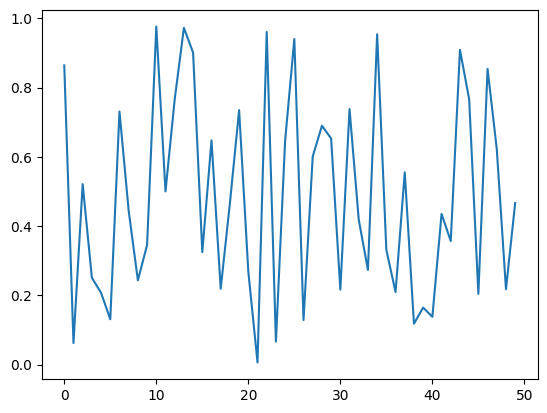

In [ ]:
plt.plot([rand() for _ in range(50)]);

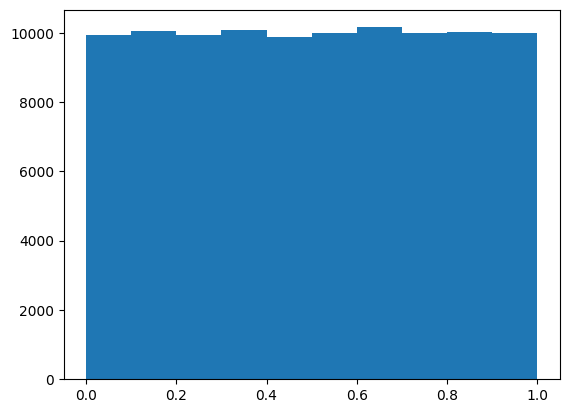

In [ ]:
plt.hist([rand() for _ in range(100000)]);

In [ ]:
%timeit -n 10 list(chunks([rand() for _ in range(7840)], 10))

2.69 ms ± 27.2 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%timeit -n 10 torch.randn(784,10)

35.8 μs ± 24 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Matrix multiplication

In [ ]:
torch.manual_seed(1)
weights = torch.randn(784,10)
bias = torch.zeros(10)

In [ ]:
m1 = x_valid[:5]
m2 = weights

In [ ]:
m1.shape,m2.shape

(torch.Size([5, 784]), torch.Size([784, 10]))

In [ ]:
ar,ac = m1.shape # n_rows * n_cols
br,bc = m2.shape
(ar,ac),(br,bc)

((5, 784), (784, 10))

In [ ]:
t1 = torch.zeros(ar, bc)
t1.shape

torch.Size([5, 10])

In [ ]:
for i in range(ar):         # 5
    for j in range(bc):     # 10
        for k in range(ac): # 784
            t1[i,j] += m1[i,k] * m2[k,j]

In [ ]:
t1

tensor([[-10.9417,  -0.6844,  -7.0038,  -4.0066,  -2.0857,  -3.3588,   3.9127,
          -3.4375, -11.4696,  -2.1153],
        [ 14.5430,   5.9977,   2.8914,  -4.0777,   6.5914, -14.7383,  -9.2787,
           2.1577, -15.2772,  -2.6758],
        [  2.2204,  -3.2171,  -4.7988,  -6.0453,  14.1661,  -8.9824,  -4.7922,
          -5.4446, -20.6758,  13.5657],
        [ -6.7097,   8.8998,  -7.4611,  -7.8966,   2.6994,  -4.7260, -11.0278,
         -12.9776,  -6.4443,   3.6376],
        [ -2.4444,  -6.4034,  -2.3984,  -9.0371,  11.1772,  -5.7724,  -8.9214,
          -3.7862,  -8.9827,   5.2797]])

In [ ]:
t1.shape

torch.Size([5, 10])

In [ ]:
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
t1

tensor([[-10.94,  -0.68,  -7.00,  -4.01,  -2.09,  -3.36,   3.91,  -3.44, -11.47,  -2.12],
        [ 14.54,   6.00,   2.89,  -4.08,   6.59, -14.74,  -9.28,   2.16, -15.28,  -2.68],
        [  2.22,  -3.22,  -4.80,  -6.05,  14.17,  -8.98,  -4.79,  -5.44, -20.68,  13.57],
        [ -6.71,   8.90,  -7.46,  -7.90,   2.70,  -4.73, -11.03, -12.98,  -6.44,   3.64],
        [ -2.44,  -6.40,  -2.40,  -9.04,  11.18,  -5.77,  -8.92,  -3.79,  -8.98,   5.28]])

In [ ]:
import numpy as np
np.set_printoptions(precision=2, linewidth=140)

In [ ]:
def matmul(a,b):
    (ar,ac),(br,bc) = a.shape,b.shape
    c = torch.zeros(ar, bc)
    for i in range(ar):
        for j in range(bc):
            for k in range(ac): c[i,j] += a[i,k] * b[k,j]
    return c

In [ ]:
%time _=matmul(m1, m2)

CPU times: user 371 ms, sys: 163 μs, total: 371 ms
Wall time: 371 ms


In [ ]:
ar*bc*ac

39200

## Numba

In [ ]:
from numba import njit

介绍Numba，让我对其有足够地了解

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

**Numba** 是一个 Python 的 **即时编译（JIT - Just-In-Time）** 库。它会分析你的 Python 函数，把它编译成机器码，运行速度可以接近 C 语言。

**核心思想**：Python 慢的一个主要原因是在循环中做类型检查。Numba 在函数第一次被调用时，根据参数类型生成一个编译后的版本，之后每次调用都直接运行编译好的机器码。

**怎么用**？在你的函数上面加一个装饰器 `@njit`（或 `@jit`），就可以了：

```python
from numba import njit

@njit
def my_func(x):
    ...
```

**对比看效果**：刚才你用纯 Python 写的 `matmul` 循环需要 **352 毫秒**。加了 `@njit` 之后，同样的三重循环会快几十上百倍——因为 Numba 会直接把它编译成类似 C 的循环，不再有 Python 解释器的开销。

**但要注意**：
1. **第一次调用会慢**——因为编译发生在那一刻。后续调用就飞快了。
2. **不是所有 Python 代码都能编译**——Numba 支持的是 Python 的一个子集（数值运算、循环、NumPy 函数等），但像 `matplotlib`、文件操作等就不能直接在里面用。
3. **PyTorch tensor 默认不支持**——Numba 主要面向 **纯 Python + NumPy**。不过 PyTorch 的 `@torch.jit.script` 是它的替代方案。

要不要试试在你的 `matmul` 上直接加个 `@njit`，看看运行时间的变化？

<details class='token-usage-details'><summary>$0.0006</summary>

`total=16,827 | in=16,426 | out=401 | cached=88.8% | reasoning=50 | searches=0 | $0.0006`

</details>


In [ ]:
np.array([1, 2, 3]) * np.array([4, 5, 6])

array([ 4, 10, 18])

In [ ]:
@njit
def dot(a,b):
    res = 0.
    for i in range(len(a)): res+=a[i]*b[i]
    return res

In [ ]:
from numpy import array

In [ ]:
%time dot(array([1.,2,3]),array([2.,3,4]))

CPU times: user 4.34 s, sys: 75.8 ms, total: 4.42 s
Wall time: 534 ms


20.0

In [ ]:
%time dot(array([1.,2,3]),array([2.,3,4]))

CPU times: user 26 μs, sys: 3 μs, total: 29 μs
Wall time: 32.9 μs


20.0

Now only two of our loops are running in Python, not three:

In [ ]:
def matmul(a,b):
    (ar,ac),(br,bc) = a.shape,b.shape
    c = torch.zeros(ar, bc)
    for i in range(ar):
        for j in range(bc): c[i,j] = dot(a[i,:], b[:,j])
    return c

In [ ]:
m1a,m2a = m1.numpy(),m2.numpy()

In [ ]:
from fastcore.test import *

In [ ]:
test_close(t1,matmul(m1a, m2a))

In [ ]:
%timeit -n 50 matmul(m1a,m2a)

210 μs ± 6.07 μs per loop (mean ± std. dev. of 7 runs, 50 loops each)


## Elementwise ops

[TryAPL](https://tryapl.org/)

In [ ]:
a = tensor([10., 6, -4])
b = tensor([2., 8, 7])
a,b

(tensor([10.,  6., -4.]), tensor([2., 8., 7.]))

In [ ]:
a + b

tensor([12., 14.,  3.])

In [ ]:
(a < b).float().mean()

tensor(0.67)

In [ ]:
m = tensor([[1., 2, 3], [4,5,6], [7,8,9]]); m

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

Frobenius norm:

$$\| A \|_F = \left( \sum_{i,j=1}^n | a_{ij} |^2 \right)^{1/2}$$

*Hint*: you don't normally need to write equations in LaTeX yourself, instead, you can click 'edit' in Wikipedia and copy the LaTeX from there (which is what I did for the above equation). Or on arxiv.org, click "Download: Other formats" in the top right, then "Download source"; rename the downloaded file to end in `.tgz` if it doesn't already, and you should find the source there, including the equations to copy and paste. This is the source LaTeX that I pasted to render the equation above:

```latex
$$\| A \|_F = \left( \sum_{i,j=1}^n | a_{ij} |^2 \right)^{1/2}$$
```

用费曼视角讲解Frobenius norm

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好的，我们来用 **费曼** 的视角理解 Frobenius 范数。

费曼教人有一个特点：**先问一个很自然的问题**。

---

**问题**：有一个 3×3 的矩阵——

\[
m = \begin{pmatrix}
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 9
\end{pmatrix}
\]

如果我说"这个矩阵有多大"，你会怎么回答？

你可能会说"它有 9 个数字"。没错。但如果我们想要一个**单个数字**来描述它整体的"大小"呢？

---

**费曼会怎么做**：他会把矩阵想象成一堆数字散落在桌面上。然后问：我们如何度量这堆数字的"总长度"？

一个很自然的想法：把每个数字平方，加起来，再开方。就像求一个向量的长度一样。

所以对于矩阵 \(A\)，它的 Frobenius 范数就是：

\[
\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2}
\]

**用中文说**：把矩阵里每个数都平方，全部加起来，然后开根号。

---

**直觉**：它就是一个向量的"长度公式"——只不过这个向量被排列成了一个方形（矩阵）。所以你可以把矩阵**拉直**成一个长向量，再求它的欧几里得长度。

回到例子：

```python
m = tensor([[1., 2, 3], [4,5,6], [7,8,9]])
```

用 Python 算一下：

```python
(m**2).sum().sqrt()
```

你要不要试试看结果是多少？

<details class='token-usage-details'><summary>$0.0005</summary>

`total=18,691 | in=18,285 | out=406 | cached=92.4% | reasoning=57 | searches=0 | $0.0005`

</details>


In [ ]:
sf = (m*m).sum()
sf

tensor(285.)

In [ ]:
sf.sqrt()

tensor(16.88)

In [ ]:
m[2,:],m[:,2]

(tensor([7., 8., 9.]), tensor([3., 6., 9.]))

In [ ]:
m[2]

tensor([7., 8., 9.])

In [ ]:
def matmul(a,b):
    (ar,ac),(br,bc) = a.shape,b.shape
    c = torch.zeros(ar, bc)
    for i in range(ar):
        for j in range(bc): c[i,j] = (a[i,:] * b[:,j]).sum()
    return c

In [ ]:
test_close(t1,matmul(m1, m2))

In [ ]:
%timeit -n 50 _=matmul(m1, m2)

428 μs ± 6.37 μs per loop (mean ± std. dev. of 7 runs, 50 loops each)


In [ ]:
def matmul(a,b):
    (ar,ac),(br,bc) = a.shape,b.shape
    c = torch.zeros(ar, bc)
    for i in range(ar):
        for j in range(bc): c[i,j] = torch.dot(a[i,:], b[:,j])
    return c

In [ ]:
test_close(t1,matmul(m1, m2))

In [ ]:
%timeit -n 50 _=matmul(m1, m2)

352 μs ± 7.24 μs per loop (mean ± std. dev. of 7 runs, 50 loops each)


## Broadcasting

The term **broadcasting** describes how arrays with different shapes are treated during arithmetic operations.

From the [Numpy Documentation](https://docs.scipy.org/doc/numpy-1.10.0/user/basics.broadcasting.html):

    The term broadcasting describes how numpy treats arrays with 
    different shapes during arithmetic operations. Subject to certain 
    constraints, the smaller array is “broadcast” across the larger 
    array so that they have compatible shapes. Broadcasting provides a 
    means of vectorizing array operations so that looping occurs in C
    instead of Python. It does this without making needless copies of 
    data and usually leads to efficient algorithm implementations.
    
In addition to the efficiency of broadcasting, it allows developers to write less code, which typically leads to fewer errors.

*This section was adapted from [Chapter 4](http://nbviewer.jupyter.org/github/fastai/numerical-linear-algebra/blob/master/nbs/4.%20Compressed%20Sensing%20of%20CT%20Scans%20with%20Robust%20Regression.ipynb#4.-Compressed-Sensing-of-CT-Scans-with-Robust-Regression) of the fast.ai [Computational Linear Algebra](https://github.com/fastai/numerical-linear-algebra) course.*

### Broadcasting with a scalar

In [ ]:
a

tensor([10.,  6., -4.])

In [ ]:
a > 0

tensor([ True,  True, False])

How are we able to do `a > 0`?  0 is being **broadcast** to have the same dimensions as a.

For instance you can normalize our dataset by subtracting the mean (a scalar) from the entire data set (a matrix) and dividing by the standard deviation (another scalar), using broadcasting.

Other examples of broadcasting with a scalar:

In [ ]:
a + 1

tensor([11.,  7., -3.])

In [ ]:
m

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

In [ ]:
2*m

tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.],
        [14., 16., 18.]])

### Broadcasting a vector to a matrix

Although broadcasting a scalar is an idea that dates back to APL, the more powerful idea of broadcasting across higher rank tensors [comes from](https://mail.python.org/pipermail/matrix-sig/1995-November/000143.html) a little known language called [Yorick](https://software.llnl.gov/yorick-doc/manual/yorick_50.html).

We can also broadcast a vector to a matrix:

In [ ]:
c = tensor([10.,20,30]); c

tensor([10., 20., 30.])

In [ ]:
m

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

In [ ]:
m.shape,c.shape

(torch.Size([3, 3]), torch.Size([3]))

In [ ]:
m + c

tensor([[11., 22., 33.],
        [14., 25., 36.],
        [17., 28., 39.]])

In [ ]:
c + m

tensor([[11., 22., 33.],
        [14., 25., 36.],
        [17., 28., 39.]])

In [ ]:
t = c.expand_as(m)

In [ ]:
t

tensor([[10., 20., 30.],
        [10., 20., 30.],
        [10., 20., 30.]])

In [ ]:
m + t

tensor([[11., 22., 33.],
        [14., 25., 36.],
        [17., 28., 39.]])

We don't really copy the rows, but it looks as if we did. In fact, the rows are given a *stride* of 0.

In [ ]:
t

tensor([[10., 20., 30.],
        [10., 20., 30.],
        [10., 20., 30.]])

In [ ]:
t.untyped_storage()

 0
 0
 32
 65
 0
 0
 160
 65
 0
 0
 240
 65
[torch.storage.UntypedStorage(device=cpu) of size 12]

explain the results of t.untyped_storage()

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's decode what those bytes mean.

**First, the big picture**: `t` is a 3×3 tensor, so if it actually stored 9 numbers (each float32 = 4 bytes), the storage would be **36 bytes**. But `t.untyped_storage()` shows only **12 bytes** — because the data was **not actually copied**.

**The raw bytes** (in little-endian, which is standard on x86):

| Bytes (hex) | Float32 value |
|---|---|
| `00 00 20 41` | 10.0 |
| `00 00 A0 41` | 20.0 |
| `00 00 F0 41` | 30.0 |

**How to read `65, 32` etc**: Those numbers are decimal representations of the bytes in hex. Let's check: `65` decimal = `0x41`, `32` decimal = `0x20`. So the first 4 bytes are `00 00 32 65` → in hex: `00 00 20 41`. As an IEEE 754 float32:

```
0x41200000:
  sign=0   exponent=10000010 (=130-127=3)   mantissa=1.01₂ (=1.25)
  → 1.25 × 2³ = 10.0 ✓
```

**The key insight**: Only **3 values** are stored (10, 20, 30), occupying just 12 bytes total. The 3×3 shape is achieved via **stride** — the tensor knows that for row indices 0, 1, 2, the pointer stays at the same starting position (stride of 0 for the first dimension), so it *looks* like 9 values but really reuses the same 3 numbers without copying.

Want to check the strides yourself? Try `t.stride()`.

<details class='token-usage-details'><summary>$0.0014</summary>

`total=22,508 | in=21,320 | out=1,188 | cached=79.8% | reasoning=782 | searches=0 | $0.0014`

</details>


In [ ]:
t.stride(), t.shape

((0, 1), torch.Size([3, 3]))

You can index with the special value [None] or use `unsqueeze()` to convert a 1-dimensional array into a 2-dimensional array (although one of those dimensions has value 1).

In [ ]:
c.unsqueeze(0), c[None, :]

(tensor([[10., 20., 30.]]), tensor([[10., 20., 30.]]))

In [ ]:
c.shape, c.unsqueeze(0).shape, c[None, :].shape

(torch.Size([3]), torch.Size([1, 3]), torch.Size([1, 3]))

In [ ]:
c.unsqueeze(1), c[:, None]

(tensor([[10.],
         [20.],
         [30.]]),
 tensor([[10.],
         [20.],
         [30.]]))

In [ ]:
c.shape, c.unsqueeze(1).shape

(torch.Size([3]), torch.Size([3, 1]))

You can always skip trailling ':'s. And '...' means '*all preceding dimensions*'

In [ ]:
c[None].shape,c[...,None].shape

(torch.Size([1, 3]), torch.Size([3, 1]))

In [ ]:
c[:,None].expand_as(m)

tensor([[10., 10., 10.],
        [20., 20., 20.],
        [30., 30., 30.]])

In [ ]:
m + c[:,None]

tensor([[11., 12., 13.],
        [24., 25., 26.],
        [37., 38., 39.]])

In [ ]:
m + c[None,:]

tensor([[11., 22., 33.],
        [14., 25., 36.],
        [17., 28., 39.]])

### Broadcasting Rules

In [ ]:
c[None,:]

tensor([[10., 20., 30.]])

In [ ]:
c[None,:].shape

torch.Size([1, 3])

In [ ]:
c[:,None]

tensor([[10.],
        [20.],
        [30.]])

In [ ]:
c[:,None].shape

torch.Size([3, 1])

In [ ]:
c[None,:] * c[:,None]

tensor([[100., 200., 300.],
        [200., 400., 600.],
        [300., 600., 900.]])

In [ ]:
c[None] > c[:,None]

tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

In [ ]:
m*m

tensor([[ 1.,  4.,  9.],
        [16., 25., 36.],
        [49., 64., 81.]])

When operating on two arrays/tensors, Numpy/PyTorch compares their shapes element-wise. It starts with the **trailing dimensions**, and works its way forward. Two dimensions are **compatible** when

- they are equal, or
- one of them is 1, in which case that dimension is broadcasted to make it the same size

Arrays do not need to have the same number of dimensions. For example, if you have a `256*256*3` array of RGB values, and you want to scale each color in the image by a different value, you can multiply the image by a one-dimensional array with 3 values. Lining up the sizes of the trailing axes of these arrays according to the broadcast rules, shows that they are compatible:

    Image  (3d array): 256 x 256 x 3
    Scale  (1d array):             3
    Result (3d array): 256 x 256 x 3

The [numpy documentation](https://docs.scipy.org/doc/numpy-1.13.0/user/basics.broadcasting.html#general-broadcasting-rules) includes several examples of what dimensions can and can not be broadcast together.

## Matmul with broadcasting

In [ ]:
digit = m1[0]
digit.shape,m2.shape

(torch.Size([784]), torch.Size([784, 10]))

In [ ]:
digit[:,None].shape

torch.Size([784, 1])

In [ ]:
digit[:,None].expand_as(m2).shape

torch.Size([784, 10])

In [ ]:
(digit[:,None]*m2).shape

torch.Size([784, 10])

In [ ]:
m1.shape, m2.shape

(torch.Size([5, 784]), torch.Size([784, 10]))

In [ ]:
m1[0].shape

torch.Size([784])

In [ ]:
m1[:, 2].shape

torch.Size([5])

为什么m1[0].shape是[784]而不是[1, 784]

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！关键区别在于 **索引方式**：

| 写法 | 含义 | shape |
|---|---|---|
| `m1[0]` | 选中**第 0 行**，把那一个维度"去掉" | `[784]` |
| `m1[0:1]` | 选中**从 0 到 1 行的一个切片**，保留维度 | `[1, 784]` |
| `m1[[0]]` | 用列表索引，也是保留维度 | `[1, 784]` |

**直觉**：方括号里放一个**整数**，就是"把这一层剥开，拿到里面的东西"；放一个**切片**或**列表**，就是"取一个子集，外层容器还在"。

可以自己试试：

```python
m1[0].shape      # torch.Size([784])
m1[0:1].shape    # torch.Size([1, 784])
m1[[0]].shape    # torch.Size([1, 784])
```

这跟 Python 列表的行为很像：

```python
lst = [[1,2,3], [4,5,6]]
lst[0]     # [1,2,3]       —— 拿到元素
lst[0:1]   # [[1,2,3]]     —— 拿到列表
```

想看看 `m1[0]` 和 `m1[0:1]` 在矩阵乘法里用起来有什么不同吗？

<details class='token-usage-details'><summary>$0.0008</summary>

`total=24,428 | in=23,944 | out=484 | cached=88.2% | reasoning=160 | searches=0 | $0.0008`

</details>


那为什么m1[0, :].shape也是[784]

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

同样道理——**整数索引会去掉那个维度**，无论是写在前面还是后面：

| 写法 | 含义 | shape |
|---|---|---|
| `m1[0]` | 第 0 行（隐式等价于 `m1[0, :]`） | `[784]` |
| `m1[0, :]` | 第 0 行，所有列——**0 是整数，去掉；: 是切片，保留** | `[784]` |
| `m1[0:1, :]` | 第 0 到 1 行——**0:1 是切片，保留维度** | `[1, 784]` |

规则很简单：**整数 squeeze，切片 keep**，与位置无关。

想试试看 `m1[:, 0]` 跟 `m1[:, 0:1]` 的区别吗？

<details class='token-usage-details'><summary>$0.0003</summary>

`total=24,759 | in=24,338 | out=421 | cached=96.8% | reasoning=223 | searches=0 | $0.0003`

</details>


In [ ]:
def matmul(a,b):
    (ar,ac),(br,bc) = a.shape,b.shape
    c = torch.zeros(ar, bc)
    for i in range(ar):
#       c[i,j] = (a[i,:] * b[:,j]).sum()      # previous version
        c[i]   = (a[i,:,None] * b).sum(dim=0) # broadcast version
    return c

In [ ]:
test_close(t1,matmul(m1, m2))

In [ ]:
%timeit -n 50 _=matmul(m1, m2)

59.6 μs ± 6.5 μs per loop (mean ± std. dev. of 7 runs, 50 loops each)


Our time has gone from ~500ms to <0.1ms, an over 5000x improvement! We can run on the whole dataset now.

In [ ]:
tr = matmul(x_train, weights)
tr

tensor([[  0.96,  -2.96,  -2.11,  ..., -15.09, -17.69,   0.60],
        [  6.89,  -0.34,   0.79,  ..., -17.13, -25.36,  16.23],
        [-10.18,   7.38,   4.13,  ...,  -6.73,  -6.79,  -1.58],
        ...,
        [  7.40,   7.64,  -3.50,  ...,  -1.02, -16.22,   2.07],
        [  3.25,   9.52,  -9.37,  ...,   2.98, -19.58,  -1.96],
        [ 15.70,   4.12,  -5.62,  ...,   8.08, -12.21,   0.42]])

In [ ]:
tr.shape

torch.Size([50000, 10])

In [ ]:
%time _=matmul(x_train, weights)

CPU times: user 1.11 s, sys: 4.59 ms, total: 1.11 s
Wall time: 558 ms


https://mathworld.wolfram.com/VectorNorm.html

用费曼视角以中文语境讲解范数(Norm)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me first read the article to get the technical details right.


<details class='tool-usage-details'>
<summary><code>read_url(url=&#x27;https://mathworld.wolfram.com/VectorNorm…&#x27;, as_md=True)→&#x27;![](https://mathworld.wolfram.com/images…&#x27;</code></summary>

```json
{
  "id": "call_00_4uhFRHXpswhk0IwR0Fo20523",
  "call": {
    "function": "read_url",
    "arguments": {
      "url": "https://mathworld.wolfram.com/VectorNorm.html",
      "as_md": "True"
    }
  },
  "result": "<TRUNCATED>\u2026//mathworld.wolfram.com/images/header/menu-icon.png) TOPICS\n\n[](https://www.wolfram.com/mathematica/) [](https://wolframalpha.com/) [](/) [](https://www.wolfram.com/mathematica/) [](https://wolframalpha.com/) [](/) ![Search](https://mathworld.wolfram.com/images/header/search-icon.png) ![Close](https://mathworld.wolfram.com/images/header/menu-close.png) ![](https://mathworld.wolfram.com/images/sidebar/menu-close.png) ![Search](https://mathworld.wolfram.com/images/header/search-icon.png) [ Algebra ](/topics/Algebra.html) [ Applied Mathematics ](/topics/AppliedMathematics.html) [ Calculus and Analysis ](/topics/CalculusandAnalysis.html) [ Discrete Mathematics ](/topics/DiscreteMathematics.html) [ Foundations of Mathematics ](/topics/FoundationsofMathematics.html) [ Geometry ](/topics/Geometry.html) [ History and Terminology ](/topics/HistoryandTerminology.html) [ Number Theory ](/topics/NumberTheory.html) [ Probability and Statistics ](/topics/ProbabilityandStatistics.html) [ Recreational Mathematics ](/topics/RecreationalMathematics.html) [ Topology ](/topics/Topology.html) [ Alphabetical Index ](/letters/) [ New in MathWorld ](/whatsnew/)\n\n  * [Algebra](/topics/Algebra.html)\n  * [Vector Algebra](/topics/VectorAlgebra.html)\n\n\n\n# Vector Norm\n\n* * *\n\n[![DOWNLOAD Mathematica Notebook](https://mathworld.wolfram.com/images/entries/download-notebook-icon.png)Download Wolfram Notebook](/notebooks/LinearAlgebra/VectorNorm.nb)\n\nGiven an ![n](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline1.svg)-dimensional [vector](/Vector.html)\n\n![ x=[x_1; x_2; |; x_n], ](https://mathworld.wolfram.com/images/equations/VectorNorm/NumberedEquation1.svg)|  (1)   \n---|---  \n  \na general vector norm ![|x|](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline2.svg), sometimes written with a [double bar](/DoubleBar.html) as ![||x||](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline3.svg), is a [nonnegative](/Nonnegative.html) [norm](/Norm.html) defined such that \n\n1\\. ![|x|>0](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline4.svg) when ![x!=0](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline5.svg) and ![|x|=0](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline6.svg) [iff](/Iff.html) ![x=0](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline7.svg). \n\n2\\. ![|kx|=|k||x|](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline8.svg) for any [scalar](/Scalar.html) ![k](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline9.svg). \n\n3\\. ![|x+y|<=|x|+|y|](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline10.svg). \n\nIn this work, a [single bar](/SingleBar.html) is used to denote a vector norm, [absolute value](/AbsoluteValue.html), or [complex modulus](/ComplexModulus.html), while a [double bar](/DoubleBar.html) is reserved for denoting a [matrix norm](/MatrixNorm.html). \n\nThe vector norm ![|x|_p](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline11.svg) for ![p=1](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline12.svg), 2, ... is defined as \n\n![ |x|_p=(sum_(i)|x_i|^p)^(1/p). ](https://mathworld.wolfram.com/images/equations/VectorNorm/NumberedEquation2.svg)|  (2)   \n---|---  \n  \nThe ![p](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline13.svg)-norm of vector ![v](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline14.svg) is implemented as `[Norm](http://reference.wolfram.com/language/ref/Norm.html)`[_v_ , _p_], with the 2-norm being returned by `Norm`[_v_]. \n\nThe special case ![|x|_infty](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline15.svg) is defined as \n\n![ |x|_infty=max_(i)|x_i|. ](https://mathworld.wolfram.com/images/equations/VectorNorm/NumberedEquation3.svg)|  (3)   \n---|---  \n  \nThe most commonly encountered vector norm (often simply called \"the norm\" of a vector, or sometimes the magnitude of a vector) is the [L2-norm](/L2-Norm.html), given by \n\n![ |x|_2=|x|=sqrt(x_1^2+x_2^2+...+x_n^2). ](https://mathworld.wolfram.com/images/equations/VectorNorm/NumberedEquation4.svg)|  (4)   \n---|---  \n  \nThis and other types of vector norms are summarized in the following table, together with the value of the norm for the example vector ![v=(1,2,3)](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline16.svg). \n\nname| symbol| value| approx.  \n---|---|---|---  \n![L^1](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline17.svg)-norm| ![|x|_1](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline18.svg)| 6| 6.000  \n![L^2](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline19.svg)-norm| ![|x|_2](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline20.svg)| ![sqrt(14)](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline21.svg)| 3.742  \n![L^3](https://mathworld.wolfram.com/images/equations/VectorNorm/Inline22.svg)-norm| ![|x|_3](https://mathworld.wolfram.com/imag\u2026</TRUNCATED>"
}
```

</details>





好，我们来聊**范数**。

---

**费曼式问题**：给你一个向量 \((3, 4)\)，你问我"这条线段有多长"。你心里想的是几？

**你**：5。

没错。因为你用了勾股定理：\(\sqrt{3^2 + 4^2} = 5\)。

恭喜，你已经用了半辈子**范数**——只不过你管它叫"长度"。

---

**范数就是一把尺子**。它回答一个问题：**这个向量有多大？**

你刚用的那把尺子叫 **L2 范数**（也叫欧几里得范数）：

\[
\|v\|_2 = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}
\]

就是每个分量平方加起来再开方。

---

**但范数不止这一种尺子**。想想看：

- **L1 范数**：把所有分量绝对值加起来。\((3, 4)\) 的 L1 范数是 \(7\)。什么时候会用到它？比如你要计算"曼哈顿距离"——在网格上走直角，不能斜穿。

- **L∞ 范数**：只取最大的那个分量。\((3, 4)\) 的 L∞ 范数是 \(4\)。这相当于问：这堆数字里最大的有多大？

三种尺子量同一个向量 \((3, 4)\)：

| 范数 | 公式 | 结果 | 直觉 |
|---|---|---|---|
| L1 | \(\|3\| + \|4\|\) | 7 | 出租车里程 |
| L2 | \(\sqrt{3^2 + 4^2}\) | 5 | 直线距离 |
| L∞ | \(\max(3, 4)\) | 4 | 最大值 |

---

而之前学的 Frobenius 范数，其实就是把矩阵**拉直**成一个向量，然后求它的 L2 范数。所以它本质上就是矩阵界的"长度"尺子。

---

想试试在 Python 里算不同范数吗？比如算算 MNIST 里一张图片的 L1、L2、L∞ 范数各是多少？

<details class='token-usage-details'><summary>$0.0012</summary>

`total=54,298 | in=53,540 | out=758 | cached=91.8% | reasoning=209 | searches=0 | $0.0012`

</details>


L1范数为什么是7，这两种范数取平均值吗，和MAE以及MSE什么关系

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！一个个来。

---

**L1 为啥是 7？**

不是平均，就是**直接加**：

\[
\|(3,4)\|_1 = |3| + |4| = 3 + 4 = 7
\]

所有分量绝对值**总和**。L2 是平方和**再开方**：

\[
\|(3,4)\|_2 = \sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = 5
\]

**不是取平均**。平均是除以个数。L1 除以 2 叫"平均绝对误差"（MAE）；L2 平方后除以 2 再开方……不常见。更常见的是**均方误差（MSE）**：

\[
\text{MSE} = \frac{1}{n}\sum (y_i - \hat{y}_i)^2
\]

---

**和 MAE、MSE 的关系：**

| 概念 | 公式 | 和范数的关系 |
|---|---|---|
| **L1 范数** | \(\sum \|e_i\|\) | 误差向量的 L1 |
| **MAE** | \(\frac{1}{n}\sum \|e_i\|\) | L1 **除以 n** |
| **L2 范数** | \(\sqrt{\sum e_i^2}\) | 误差向量的 L2 |
| **MSE** | \(\frac{1}{n}\sum e_i^2\) | L2² **除以 n** |

很像，就是**除以个数**和**要不要开方**的差别。

---

用一个具体的例子消化一下：假设真实值 0，预测值分别是 [3, 4]（两个样本的误差向量）——上面表格里的数字可以直接套进去。

有什么想继续展开的吗？

<details class='token-usage-details'><summary>$0.0010</summary>

`total=28,076 | in=27,583 | out=493 | cached=85.8% | reasoning=93 | searches=0 | $0.0010`

</details>


我在其他教程看过L2范式就是MSE，这不对吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

不完全对，但这个混淆很常见，因为它俩确实长得很像。关键差异在两个地方：

**公式对比**（误差向量 e = [e₁, e₂, ..., eₙ]）：

| 名称 | 公式 | 除以 n 吗？ | 开方吗？ |
|---|---|---|---|
| L2 范数 | \(\sqrt{\sum e_i^2}\) | 不除 | 开方 |
| MSE | \(\frac{1}{n}\sum e_i^2\) | 除 | 不开方 |

**两个不同点**：

1. **开方**——L2 范数最后开根号，MSE 没有
2. **除以样本数**——MSE 取了平均，L2 范数没有

所以如果你看到有人说"L2 损失"或"L2 正则化"——他们通常指的是**平方和**（不开方、不平均），即 \(\sum e_i^2\)。这和 L2 范数的平方是同一个东西。

但**严格来说**，L2 范数 ≠ MSE。

---

顺带一问：其他地方指的教程具体是说什么场景？如果是机器学习里的损失函数，确实容易混用术语。

<details class='token-usage-details'><summary>$0.0008</summary>

`total=28,504 | in=28,052 | out=452 | cached=89.9% | reasoning=196 | searches=0 | $0.0008`

</details>


## Einstein summation

[Einstein summation](https://ajcr.net/Basic-guide-to-einsum/) ([`einsum`](https://numpy.org/doc/stable/reference/generated/numpy.einsum.html)) is a compact representation for combining products and sums in a general way. The key rules are:

- Repeating letters between input arrays means that values along those axes will be multiplied together.
- Omitting a letter from the output means that values along that axis will be summed.

In [ ]:
m1.shape,m2.shape

(torch.Size([5, 784]), torch.Size([784, 10]))

In [ ]:
# c[i,j] += a[i,k] * b[k,j]
# c[i,j] = (a[i,:] * b[:,j]).sum()
mr = torch.einsum('ik,kj->ikj', m1, m2)
mr.shape

torch.Size([5, 784, 10])

In [ ]:
mr.sum(dim=1)

tensor([[-10.94,  -0.68,  -7.00,  -4.01,  -2.09,  -3.36,   3.91,  -3.44, -11.47,  -2.12],
        [ 14.54,   6.00,   2.89,  -4.08,   6.59, -14.74,  -9.28,   2.16, -15.28,  -2.68],
        [  2.22,  -3.22,  -4.80,  -6.05,  14.17,  -8.98,  -4.79,  -5.44, -20.68,  13.57],
        [ -6.71,   8.90,  -7.46,  -7.90,   2.70,  -4.73, -11.03, -12.98,  -6.44,   3.64],
        [ -2.44,  -6.40,  -2.40,  -9.04,  11.18,  -5.77,  -8.92,  -3.79,  -8.98,   5.28]])

In [ ]:
torch.einsum('ik,kj->ij', m1, m2)

tensor([[-10.94,  -0.68,  -7.00,  -4.01,  -2.09,  -3.36,   3.91,  -3.44, -11.47,  -2.12],
        [ 14.54,   6.00,   2.89,  -4.08,   6.59, -14.74,  -9.28,   2.16, -15.28,  -2.68],
        [  2.22,  -3.22,  -4.80,  -6.05,  14.17,  -8.98,  -4.79,  -5.44, -20.68,  13.57],
        [ -6.71,   8.90,  -7.46,  -7.90,   2.70,  -4.73, -11.03, -12.98,  -6.44,   3.64],
        [ -2.44,  -6.40,  -2.40,  -9.04,  11.18,  -5.77,  -8.92,  -3.79,  -8.98,   5.28]])

In [ ]:
def matmul(a,b): return torch.einsum('ik,kj->ij', a, b)

In [ ]:
test_close(tr, matmul(x_train, weights), eps=1e-3)

In [ ]:
%timeit -n 5 _=matmul(x_train, weights)

21.3 ms ± 1.96 ms per loop (mean ± std. dev. of 7 runs, 5 loops each)


Can you tell me what is Einstein summation and give me more context to understand it

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Einstein summation 是一种**紧凑的记号**，用来表达各种涉及乘法和加法的运算——矩阵乘法、点积、转置、求和等等，全都可以用一行搞定。

**核心规则只有两条**：

1. **重复的字母 = 相乘**——如果两个输入数组有相同的下标字母，这些轴上的值会逐元素相乘
2. **输出里省略的字母 = 求和**——如果一个字母出现在输入里，但不在输出里，那这个轴会被求和掉

---

用矩阵乘法做例子：`C[i,j] = Σₖ A[i,k] · B[k,j]`

在 einsum 里写成：

```python
torch.einsum('ik,kj->ij', A, B)
```

- `i`、`k`、`j` 是维度的"代号"
- `k` 重复出现了（A 的 `k` 和 B 的 `k`）→ 对应轴会相乘
- `k` 在 `->` 右边消失了 → 沿着 `k` 求和
- 只剩下 `i` 和 `j` 在输出里 → 结果形状是 `[i, j]`

---

**其他例子**：

| 运算 | einsum 写法 | 说明 |
|---|---|---|
| 向量点积 | `'i,i->'` | 相同字母 `i`，输出为空 → 求和得标量 |
| 向量外积 | `'i,j->ij'` | 字母不同，不求和 → 所有元素两两相乘 |
| 矩阵转置 | `'ij->ji'` | 交换字母顺序 |
| 逐元素乘法 | `'ij,ij->ij'` | 字母完全一样，不求和 |
| 矩阵列求和 | `'ij->j'` | `i` 被省略 → 对行求和 |

---

它为什么叫"爱因斯坦"？因为爱因斯坦在物理学里用这种记号来简化张量运算——省略求和符号 Σ，约定"重复下标就是要求和"。后来 NumPy/PyTorch 把它借了过来，成为一个非常强大的工具。

想试试用 einsum 写出前面学过的 Frobenius 范数吗？或者想看某个运算的更详细拆解？

<details class='token-usage-details'><summary>$0.0061</summary>

`total=31,878 | in=31,360 | out=518 | cached=11.0% | reasoning=34 | searches=0 | $0.0061`

</details>


## pytorch op

We can use pytorch's function or operator directly for matrix multiplication.

In [ ]:
test_close(tr, x_train@weights, eps=1e-3)

In [ ]:
%timeit -n 5 _=torch.matmul(x_train, weights)

22 ms ± 930 μs per loop (mean ± std. dev. of 7 runs, 5 loops each)


## CUDA

In [ ]:
def matmul(grid, a,b,c):
    i,j = grid
    if i < c.shape[0] and j < c.shape[1]:
        tmp = 0.
        for k in range(a.shape[1]): tmp += a[i, k] * b[k, j]
        c[i,j] = tmp

In [ ]:
res = torch.zeros(ar, bc)
matmul((0,0), m1, m2, res)
res

tensor([[-10.94,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
        [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
        [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
        [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
        [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00]])

In [ ]:
def launch_kernel(kernel, grid_x, grid_y, *args, **kwargs):
    for i in range(grid_x):
        for j in range(grid_y): kernel((i,j), *args, **kwargs)

In [ ]:
res = torch.zeros(ar, bc)
launch_kernel(matmul, ar, bc, m1, m2, res)
res

tensor([[-10.94,  -0.68,  -7.00,  -4.01,  -2.09,  -3.36,   3.91,  -3.44, -11.47,  -2.12],
        [ 14.54,   6.00,   2.89,  -4.08,   6.59, -14.74,  -9.28,   2.16, -15.28,  -2.68],
        [  2.22,  -3.22,  -4.80,  -6.05,  14.17,  -8.98,  -4.79,  -5.44, -20.68,  13.57],
        [ -6.71,   8.90,  -7.46,  -7.90,   2.70,  -4.73, -11.03, -12.98,  -6.44,   3.64],
        [ -2.44,  -6.40,  -2.40,  -9.04,  11.18,  -5.77,  -8.92,  -3.79,  -8.98,   5.28]])

In [ ]:
from numba import cuda

In [ ]:
def matmul(grid, a,b,c):
    i,j = grid
    if i < c.shape[0] and j < c.shape[1]:
        tmp = 0.
        for k in range(a.shape[1]): tmp += a[i, k] * b[k, j]
        c[i,j] = tmp

In [ ]:
@cuda.jit
def matmul(a,b,c):
    i, j = cuda.grid(2)
    if i < c.shape[0] and j < c.shape[1]:
        tmp = 0.
        for k in range(a.shape[1]): tmp += a[i, k] * b[k, j]
        c[i,j] = tmp

In [ ]:
tr.shape

torch.Size([50000, 10])

In [ ]:
r = np.zeros(tr.shape)
m1g,m2g,rg = map(cuda.to_device, (x_train,weights,r))

CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:

In [ ]:
r.shape

(50000, 10)

In [ ]:
TPB = 16
rr,rc = r.shape
blockspergrid = (math.ceil(rr / TPB), math.ceil(rc / TPB))
blockspergrid

(3125, 1)

In [ ]:
matmul[blockspergrid, (TPB,TPB)](m1g,m2g,rg)
r = rg.copy_to_host()
test_close(tr, r, eps=1e-3)

In [ ]:
%%timeit -n 10
matmul[blockspergrid, (TPB,TPB)](m1g,m2g,rg)
r = rg.copy_to_host()

3.61 ms ± 708 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
m1c,m2c = x_train.cuda(),weights.cuda()

In [ ]:
r=(m1c@m2c).cpu()

In [ ]:
%timeit -n 10 r=(m1c@m2c).cpu()

458 µs ± 93.1 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


Our broadcasting version was >500ms, and our CUDA version is around 0.5ms, which is another 1000x improvement compared to broadcasting. So our total speedup is around 5 million times!